# H2 Leak Prediction

This notebook tests whether including the **`time (s)`** column improves predictive performance.

It trains and compares two versions for each target:

1. **Baseline model** using only sensor columns
2. **Extended model** using sensor columns **plus `time (s)`**

Then it:

- reports validation and test accuracy for both versions
- automatically selects the better feature set for each target
- trains tuned XGBoost models
- plots feature importance
- plots confusion matrices
- saves the final trained bundle as a `.pkl`

## Baseline features
- `compressor sensor (ppm)`
- `storage sensor (ppm)`
- `pipeline sensor (ppm)`
- `fuelcell sensor (ppm)`

## Extended features
- `time (s)`
- `compressor sensor (ppm)`
- `storage sensor (ppm)`
- `pipeline sensor (ppm)`
- `fuelcell sensor (ppm)`

## Predicted targets
- `leak_label`
- `leak location`
- `leak severity`
- `action plan`
- `phase`


## 0) Install dependencies

In [1]:
!pip install xgboost openpyxl joblib scikit-learn pandas matplotlib

In [2]:
import os
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

## 1) Configuration

In [3]:
EXCEL_FILE = "/content/sample_data/H2-Dataset.xlsx"
DATA_SHEET = "Data"
DESC_SHEET = "Des."
OUTPUT_MODEL_FILE = "hydrogen_leakage_prediction_model.pkl"

BASE_FEATURE_COLUMNS = [
    "compressor sensor (ppm)",
    "storage sensor (ppm)",
    "pipeline sensor (ppm)",
    "fuelcell sensor (ppm)",
]

TIME_FEATURE_COLUMNS = [
    "time (s)",
    "compressor sensor (ppm)",
    "storage sensor (ppm)",
    "pipeline sensor (ppm)",
    "fuelcell sensor (ppm)",
]

TARGET_COLUMNS = [
    "leak_label",
    "leak location",
    "leak severity",
    "action plan",
    "phase",
]

TEST_SIZE = 0.20
RANDOM_STATE = 42
N_ITER_SEARCH = 10
CV_FOLDS = 3

## 2) Load the dataset

In [4]:
print("Loading Excel file...")
if not os.path.exists(EXCEL_FILE):
    raise FileNotFoundError(f"Excel file not found: {EXCEL_FILE}")

data_df = pd.read_excel(EXCEL_FILE, sheet_name=DATA_SHEET)

try:
    des_df = pd.read_excel(EXCEL_FILE, sheet_name=DESC_SHEET)
    print("Loaded 'Des.' sheet successfully.")
except Exception:
    des_df = None
    print("'Des.' sheet could not be loaded. Continuing without it.")

print("\nData shape:", data_df.shape)
display(data_df.head())

print("\nColumns:")
print(list(data_df.columns))

Loading Excel file...
Loaded 'Des.' sheet successfully.

Data shape: (13320, 10)


,time (s),leak_label,leak location,leak severity,action plan,phase,compressor sensor (ppm),storage sensor (ppm),pipeline sensor (ppm),fuelcell sensor (ppm)
0,0,0,none,none,none,normal,13.16,13.79,16.64,14.61
1,5,0,none,none,none,normal,15.52,11.49,19.05,17.50
2,10,0,none,none,none,normal,19.33,16.78,17.16,21.55
3,15,0,none,none,none,normal,15.85,18.86,13.33,12.04
4,20,0,none,none,none,normal,12.90,21.76,13.25,18.36



Columns:
['time (s)', 'leak_label', 'leak location', 'leak severity', 'action plan', 'phase', 'compressor sensor (ppm)', 'storage sensor (ppm)', 'pipeline sensor (ppm)', 'fuelcell sensor (ppm)']


## 3) Validate required columns

In [5]:
required_columns = list(set(TIME_FEATURE_COLUMNS + TARGET_COLUMNS))
missing_columns = [col for col in required_columns if col not in data_df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("All required columns are present.")

All required columns are present.


## 4) Keep needed columns and clean the data

In [6]:
df = data_df[required_columns].copy()

for col in TIME_FEATURE_COLUMNS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

before_drop = len(df)
df = df.dropna(subset=TIME_FEATURE_COLUMNS + TARGET_COLUMNS).reset_index(drop=True)
after_drop = len(df)

print(f"Rows before cleaning: {before_drop}")
print(f"Rows after cleaning:  {after_drop}")
print(f"Removed rows:         {before_drop - after_drop}")

if len(df) == 0:
    raise ValueError("No valid rows remain after cleaning.")

display(df.head())

Rows before cleaning: 13320
Rows after cleaning:  13320
Removed rows:         0


,pipeline sensor (ppm),compressor sensor (ppm),phase,leak_label,leak location,fuelcell sensor (ppm),leak severity,action plan,time (s),storage sensor (ppm)
0,16.64,13.16,normal,0,none,14.61,none,none,0,13.79
1,19.05,15.52,normal,0,none,17.50,none,none,5,11.49
2,17.16,19.33,normal,0,none,21.55,none,none,10,16.78
3,13.33,15.85,normal,0,none,12.04,none,none,15,18.86
4,13.25,12.90,normal,0,none,18.36,none,none,20,21.76


## 5) Encode target columns

In [7]:
Y_raw = df[TARGET_COLUMNS].copy()

label_encoders = {}
Y_encoded = pd.DataFrame(index=Y_raw.index)

for target in TARGET_COLUMNS:
    le = LabelEncoder()
    Y_encoded[target] = le.fit_transform(Y_raw[target].astype(str))
    label_encoders[target] = le

for target in TARGET_COLUMNS:
    print(f"\n{target} classes:")
    print(list(label_encoders[target].classes_))


leak_label classes:
['0', '1']

leak location classes:
['compressor', 'fuelcell', 'none', 'pipeline', 'storage']

leak severity classes:
['large', 'medium', 'none', 'small']

action plan classes:
['controlled_shutdown', 'emergency_shutdown', 'inspect_and_repair', 'isolate_and_monitor', 'none']

phase classes:
['alarm_active', 'emergency_shutdown_and_purge', 'intermittent_leak', 'isolation_and_monitoring', 'leak_growth', 'normal', 'post_isolation_normalized', 'post_repair_normalized', 'rapid_leak_growth', 'repair_and_recovery', 'safe_shutdown_state', 'shutdown_and_purge']


## 6) Train/test split indices

In [8]:
train_idx, test_idx = train_test_split(
    df.index,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=Y_encoded["leak_label"]
)

print("Train rows:", len(train_idx))
print("Test rows: ", len(test_idx))

Train rows: 10656
Test rows:  2664


## 7) Define XGBoost search space

In [9]:
param_distributions = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 2, 3, 5],
    "gamma": [0, 0.1, 0.3, 0.5]
}

def make_xgb(num_classes, random_state=42):
    params = {
        "random_state": random_state,
        "n_jobs": -1,
        "tree_method": "hist"
    }

    if num_classes > 2:
        params["objective"] = "multi:softmax"
        params["num_class"] = num_classes
        params["eval_metric"] = "mlogloss"
    else:
        params["objective"] = "binary:logistic"
        params["eval_metric"] = "logloss"

    return XGBClassifier(**params)

def fit_search_for_target(X_train, y_train, num_classes):
    model = make_xgb(num_classes=num_classes, random_state=RANDOM_STATE)
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions,
        n_iter=N_ITER_SEARCH,
        scoring="accuracy",
        cv=cv,
        verbose=1,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    search.fit(X_train, y_train)
    return search

## 8) Compare feature sets: sensors only vs sensors + `time (s)`

Tunes both versions for each target and keeps the better one.

In [10]:
comparison_results = {}
trained_models = {}
selected_feature_sets = {}
search_results = {}

X_base = df[BASE_FEATURE_COLUMNS].copy()
X_time = df[TIME_FEATURE_COLUMNS].copy()

X_base_train = X_base.loc[train_idx]
X_base_test = X_base.loc[test_idx]

X_time_train = X_time.loc[train_idx]
X_time_test = X_time.loc[test_idx]

Y_train = Y_encoded.loc[train_idx]
Y_test = Y_encoded.loc[test_idx]

for target in TARGET_COLUMNS:
    print("\n" + "=" * 80)
    print(f"Target: {target}")

    y_train_target = Y_train[target]
    y_test_target = Y_test[target]
    num_classes = Y_encoded[target].nunique()

    print("\n--- Baseline: sensors only ---")
    search_base = fit_search_for_target(X_base_train, y_train_target, num_classes)
    model_base = search_base.best_estimator_
    pred_base = np.asarray(model_base.predict(X_base_test)).astype(int)
    base_test_acc = accuracy_score(y_test_target, pred_base)

    print(f"Best CV accuracy (base):   {search_base.best_score_:.4f}")
    print(f"Best test accuracy (base): {base_test_acc:.4f}")

    print("\n--- Extended: sensors + time (s) ---")
    search_time = fit_search_for_target(X_time_train, y_train_target, num_classes)
    model_time = search_time.best_estimator_
    pred_time = np.asarray(model_time.predict(X_time_test)).astype(int)
    time_test_acc = accuracy_score(y_test_target, pred_time)

    print(f"Best CV accuracy (time):   {search_time.best_score_:.4f}")
    print(f"Best test accuracy (time): {time_test_acc:.4f}")

    if time_test_acc > base_test_acc:
        selected_name = "sensors_plus_time"
        selected_columns = TIME_FEATURE_COLUMNS
        selected_model = model_time
        selected_search = search_time
    else:
        selected_name = "sensors_only"
        selected_columns = BASE_FEATURE_COLUMNS
        selected_model = model_base
        selected_search = search_base

    comparison_results[target] = {
        "base_cv_accuracy": search_base.best_score_,
        "base_test_accuracy": base_test_acc,
        "time_cv_accuracy": search_time.best_score_,
        "time_test_accuracy": time_test_acc,
        "selected_feature_set": selected_name
    }

    trained_models[target] = selected_model
    selected_feature_sets[target] = selected_columns
    search_results[target] = {
        "best_score": selected_search.best_score_,
        "best_params": selected_search.best_params_,
        "selected_feature_set": selected_name
    }

    print(f"\nSelected feature set for {target}: {selected_name}")


Target: leak_label

--- Baseline: sensors only ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best CV accuracy (base):   0.9808
Best test accuracy (base): 0.9816

--- Extended: sensors + time (s) ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best CV accuracy (time):   0.9869
Best test accuracy (time): 0.9861

Selected feature set for leak_label: sensors_plus_time

Target: leak location

--- Baseline: sensors only ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best CV accuracy (base):   0.8674
Best test accuracy (base): 0.8630

--- Extended: sensors + time (s) ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best CV accuracy (time):   0.8755
Best test accuracy (time): 0.8701

Selected feature set for leak location: sensors_plus_time

Target: leak severity

--- Baseline: sensors only ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best CV accuracy (base):   0.8696
Best test accuracy (base): 0.8739

-

## 9) Summary of whether `time (s)` helped

In [11]:
comparison_df = pd.DataFrame(comparison_results).T
display(comparison_df)

time_helped = comparison_df["selected_feature_set"].eq("sensors_plus_time").sum()
print(f"`time (s)` improved performance for {time_helped} out of {len(TARGET_COLUMNS)} targets.")

,base_cv_accuracy,base_test_accuracy,time_cv_accuracy,time_test_accuracy,selected_feature_set
leak_label,0.980762,0.981607,0.986862,0.986111,sensors_plus_time
leak location,0.867399,0.862988,0.875469,0.87012,sensors_plus_time
leak severity,0.869557,0.873874,0.905312,0.902027,sensors_plus_time
action plan,0.841404,0.851727,0.861674,0.860736,sensors_plus_time
phase,0.913476,0.917793,0.932714,0.938438,sensors_plus_time


`time (s)` improved performance for 5 out of 5 targets.


## 10) Detailed test evaluation

In [12]:
evaluation_results = {}

for target in TARGET_COLUMNS:
    print("\n" + "=" * 80)
    print(f"Evaluation for target: {target}")
    print(f"Using feature set: {search_results[target]['selected_feature_set']}")

    model = trained_models[target]
    feature_cols = selected_feature_sets[target]
    X_test_target = df.loc[test_idx, feature_cols]
    y_true = Y_test[target]
    y_pred = np.asarray(model.predict(X_test_target)).astype(int)

    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, digits=4)

    evaluation_results[target] = {
        "test_accuracy": acc,
        "classification_report": report,
        "selected_feature_set": search_results[target]["selected_feature_set"]
    }

    print(f"Best CV accuracy: {search_results[target]['best_score']:.4f}")
    print(f"Test accuracy:    {acc:.4f}")
    print(report)


Evaluation for target: leak_label
Using feature set: sensors_plus_time
Best CV accuracy: 0.9869
Test accuracy:    0.9861
              precision    recall  f1-score   support

           0     0.9869    0.9889    0.9879      1527
           1     0.9850    0.9824    0.9837      1137

    accuracy                         0.9861      2664
   macro avg     0.9860    0.9856    0.9858      2664
weighted avg     0.9861    0.9861    0.9861      2664


Evaluation for target: leak location
Using feature set: sensors_plus_time
Best CV accuracy: 0.8755
Test accuracy:    0.8701
              precision    recall  f1-score   support

           0     0.9002    0.8459    0.8722       597
           1     0.8968    0.8905    0.8936       566
           2     0.7487    0.9105    0.8217       324
           3     0.9164    0.8470    0.8803       608
           4     0.8530    0.8770    0.8648       569

    accuracy                         0.8701      2664
   macro avg     0.8630    0.8742    0.8665   

## 11) Show decoded sample predictions

In [13]:
sample_idx = list(test_idx[:5])
comparison_pred_df = pd.DataFrame(index=range(len(sample_idx)))

for target in TARGET_COLUMNS:
    model = trained_models[target]
    feature_cols = selected_feature_sets[target]

    X_sample = df.loc[sample_idx, feature_cols]
    y_true_enc = Y_encoded.loc[sample_idx, target].values
    y_pred_enc = np.asarray(model.predict(X_sample)).astype(int)

    comparison_pred_df[f"{target}_true"] = label_encoders[target].inverse_transform(y_true_enc)
    comparison_pred_df[f"{target}_pred"] = label_encoders[target].inverse_transform(y_pred_enc)

display(comparison_pred_df)

,leak_label_true,leak_label_pred,leak location_true,leak location_pred,leak severity_true,leak severity_pred,action plan_true,action plan_pred,phase_true,phase_pred
0,1,1,compressor,compressor,medium,medium,controlled_shutdown,controlled_shutdown,shutdown_and_purge,shutdown_and_purge
1,0,0,pipeline,pipeline,small,small,inspect_and_repair,inspect_and_repair,post_repair_normalized,post_repair_normalized
2,1,1,pipeline,pipeline,small,small,inspect_and_repair,inspect_and_repair,alarm_active,alarm_active
3,1,1,storage,storage,medium,medium,controlled_shutdown,controlled_shutdown,shutdown_and_purge,alarm_active
4,0,0,compressor,storage,medium,medium,controlled_shutdown,inspect_and_repair,normal,normal


## 12) Feature importance plots

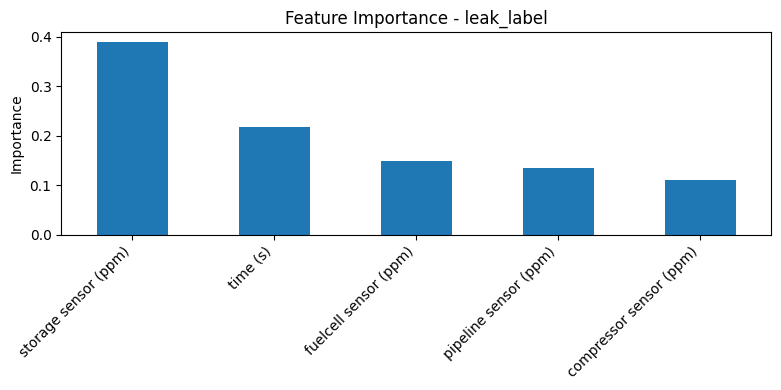

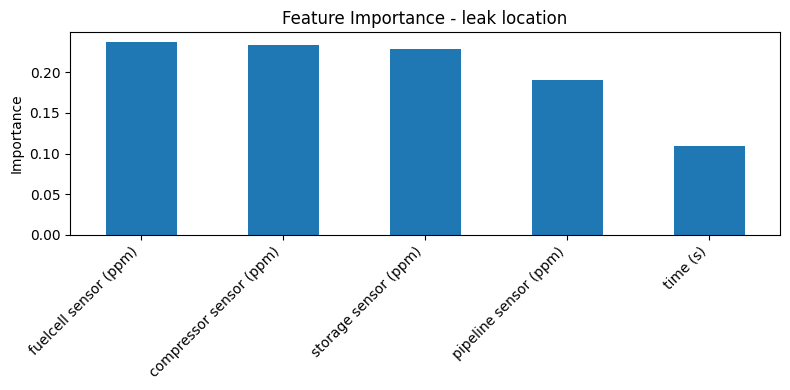

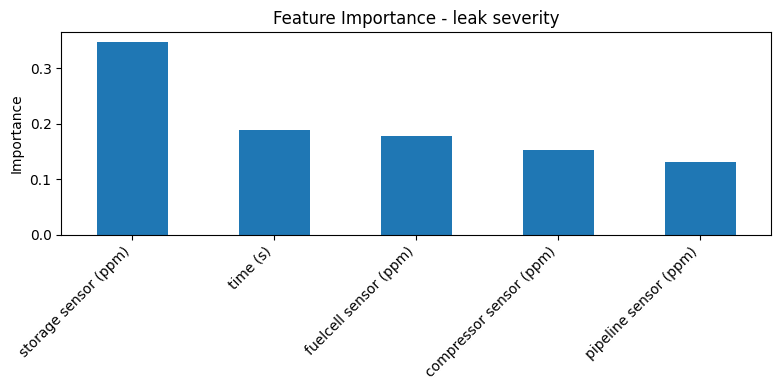

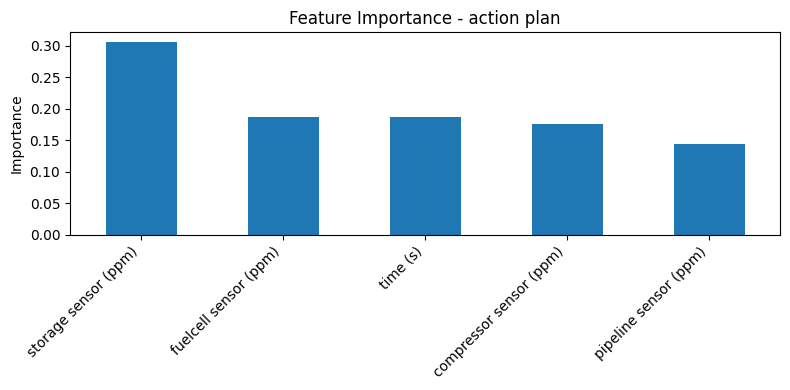

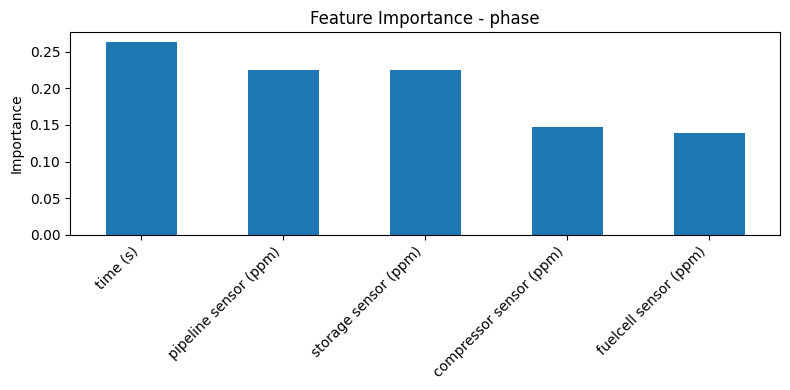

In [14]:
for target in TARGET_COLUMNS:
    model = trained_models[target]
    feature_cols = selected_feature_sets[target]
    importances = model.feature_importances_

    fi = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

    plt.figure(figsize=(8, 4))
    fi.plot(kind="bar")
    plt.title(f"Feature Importance - {target}")
    plt.ylabel("Importance")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## 13) Confusion matrices

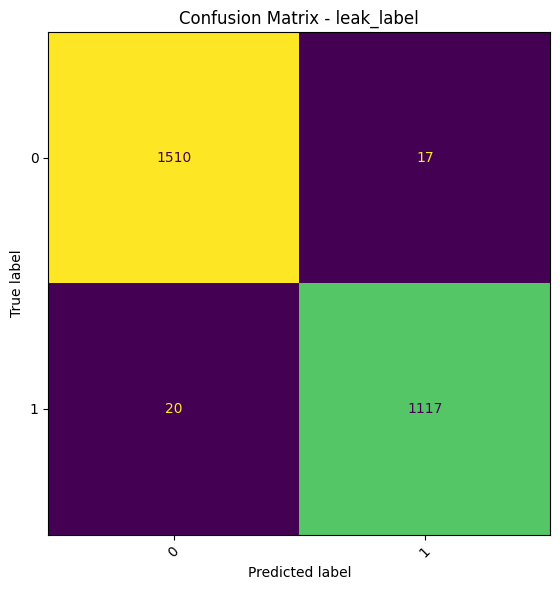

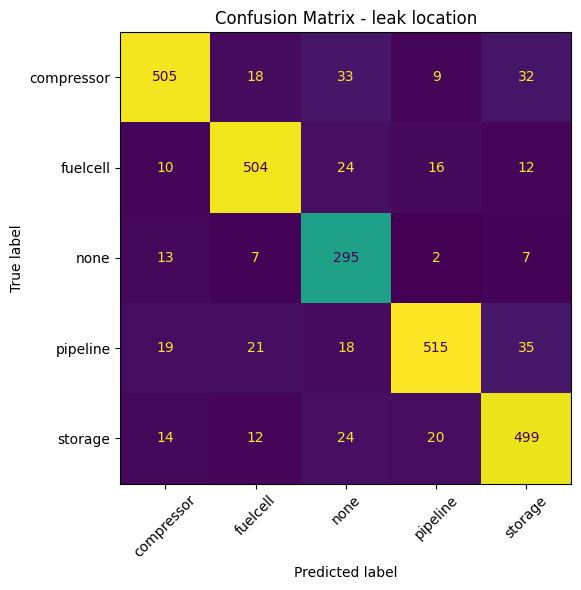

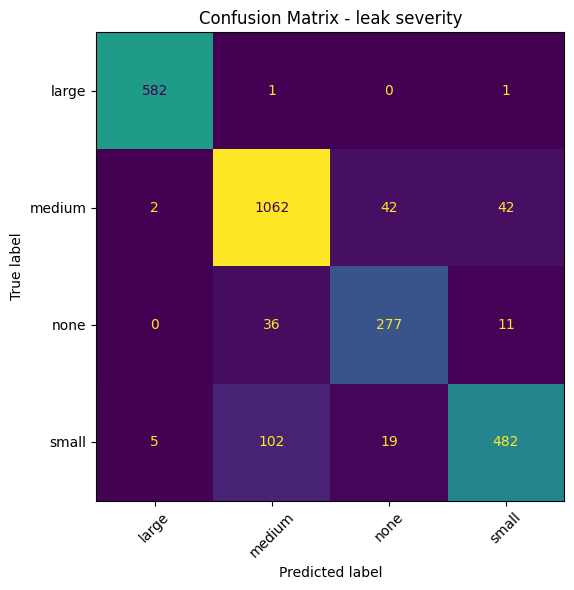

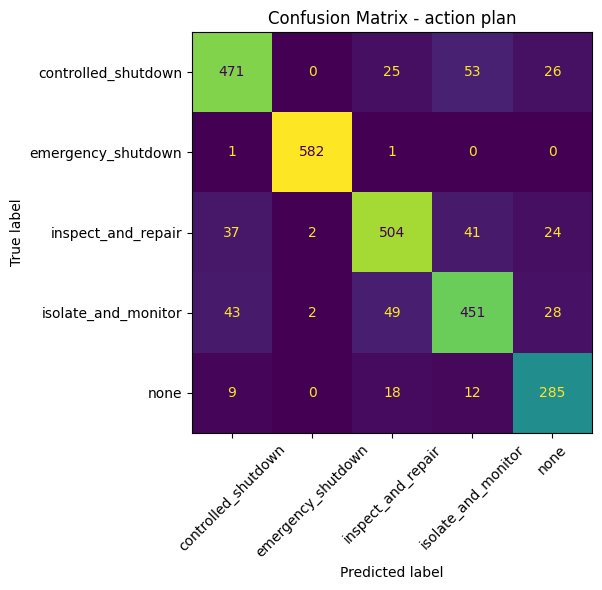

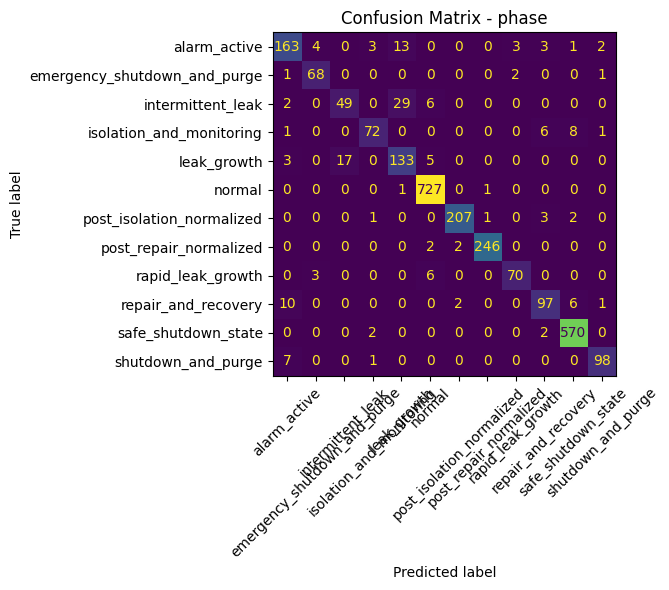

In [15]:
for target in TARGET_COLUMNS:
    model = trained_models[target]
    feature_cols = selected_feature_sets[target]
    X_test_target = df.loc[test_idx, feature_cols]
    y_true = Y_test[target]
    y_pred = np.asarray(model.predict(X_test_target)).astype(int)

    labels = np.arange(len(label_encoders[target].classes_))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoders[target].classes_
    )
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(f"Confusion Matrix - {target}")
    plt.tight_layout()
    plt.show()

## 14) Save the trained bundle

In [16]:
model_bundle = {
    "models": trained_models,
    "label_encoders": label_encoders,
    "base_feature_columns": BASE_FEATURE_COLUMNS,
    "time_feature_columns": TIME_FEATURE_COLUMNS,
    "target_columns": TARGET_COLUMNS,
    "selected_feature_sets": selected_feature_sets,
    "search_results": search_results,
    "comparison_results": comparison_results,
    "evaluation_results": evaluation_results,
}

joblib.dump(model_bundle, OUTPUT_MODEL_FILE)
print(f"Saved trained bundle to: {OUTPUT_MODEL_FILE}")

Saved trained bundle to: hydrogen_leakage_prediction_model.pkl


## 15) Inference on new data

In [17]:
bundle = joblib.load(OUTPUT_MODEL_FILE)

models = bundle["models"]
label_encoders = bundle["label_encoders"]
selected_feature_sets = bundle["selected_feature_sets"]
target_columns = bundle["target_columns"]

new_row = {
    "time (s)": 120,
    "compressor sensor (ppm)": 20.5,
    "storage sensor (ppm)": 15.2,
    "pipeline sensor (ppm)": 18.9,
    "fuelcell sensor (ppm)": 14.7
}

predictions = {}

for target in target_columns:
    feature_cols = selected_feature_sets[target]
    new_data = pd.DataFrame([{col: new_row[col] for col in feature_cols}])

    pred_encoded = np.asarray(models[target].predict(new_data)).astype(int)[0]
    pred_label = label_encoders[target].inverse_transform([pred_encoded])[0]
    predictions[target] = pred_label

print("Decoded predictions:")
print(predictions)

Decoded predictions:
{'leak_label': '0', 'leak location': 'none', 'leak severity': 'none', 'action plan': 'none', 'phase': 'normal'}
